# 05 — Paper-inspired strategy replications: reversal, momentum, and risk management

This notebook turns several research-paper ideas into small, readable ETF experiments. The point is not to reproduce every detail of an academic paper. The point is to understand the mechanism, state a fair adaptation, and test it with the same cost model and untouched test period used everywhere else in this library.

> Educational research only. This notebook is not investment advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Start with the assumptions, then follow the data and rule definitions. The tables and charts report the formal test period. Finish with <strong>What went well / what went wrong</strong> — that is where the research judgment and limitations are made explicit.
</div>


## 🧭 First, understand what is and is not being replicated

Academic studies often use thousands of individual stocks, market-cap weighting, long-short portfolios, monthly or daily portfolio formation, survivorship-bias controls, and carefully constructed point-in-time datasets. This notebook uses seven liquid ETFs, long-only weights, adjusted Yahoo Finance closes, monthly rebalancing, and a simple transaction-cost assumption. Those differences matter.

So the results below are paper-inspired adaptations, not claims that the published returns have been reproduced. A useful replication question is: does the basic signal still produce an interesting risk/return tradeoff after the adaptation, costs, and a chronological test split?

| Paper idea | Signal tested here | Main caveat |
|---|---|---|
| Jegadeesh (1990) | Buy the recent ETF losers: short-term reversal | The paper studies individual stocks and portfolio sorts; this is long-only and cross-asset. |
| Jegadeesh & Titman (1993) | Buy 12-month winners while skipping the most recent month: 12-1 momentum | The original design has stock portfolios and repeated holding periods; this version rebalances ETFs monthly. |
| 52-week-high momentum research | Buy assets close to their prior 52-week high | A small ETF universe is much less granular than an international stock universe. |
| Newer semivolatility-managed research | Apply inverse downside-volatility weights to momentum-selected assets | This is a transparent risk-control adaptation, not the paper's full stock-level implementation. |

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.backtest import split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import (
    cross_sectional_momentum_weights,
    downside_volatility_momentum_weights,
    equal_weight_weights,
    fifty_two_week_high_weights,
    run_portfolio_backtest,
    short_term_reversal_weights,
)
from src.research import comparison_table, metrics_for_period

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data and assumptions

The universe is SPY, QQQ, IWM, EFA, EEM, TLT, and GLD. This gives us equities, bonds, and gold, but it is still a tiny universe. We use daily adjusted closes from 2010 onward, rebalance at the first trading day of each month, charge 10 basis points per unit of absolute weight change, and reserve the final 20% of observations as the test period. SPY is the external benchmark; equal weight is an internal control.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD']

if USE_DEMO_DATA:
    close = pd.concat(
        [make_demo_ohlcv(periods=2_000, seed=i + 1)['close'].rename(ticker) for i, ticker in enumerate(TICKERS)],
        axis=1,
    )
else:
    try:
        close = load_price_panel(TICKERS, '2010-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat(
            [make_demo_ohlcv(periods=2_000, seed=i + 1)['close'].rename(ticker) for i, ticker in enumerate(TICKERS)],
            axis=1,
        )

splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')
print({name: (part.index.min().date(), part.index.max().date(), len(part)) for name, part in splits.items()})

Data: 2010-01-04 through 2025-12-31 (4,024 common trading days)
{'train': (datetime.date(2010, 1, 4), datetime.date(2019, 8, 6), 2414), 'validation': (datetime.date(2019, 8, 7), datetime.date(2022, 10, 14), 805), 'test': (datetime.date(2022, 10, 17), datetime.date(2025, 12, 31), 805)}


## 📚 The research sources

- [Evidence of Predictable Behavior of Security Returns — Jegadeesh (1990)](https://doi.org/10.1111/j.1540-6261.1990.tb05110.x) motivates the short-term reversal experiment: recent losers can behave differently from recent winners over short horizons.
- [Returns to Buying Winners and Selling Losers — Jegadeesh and Titman (1993)](https://doi.org/10.1111/j.1540-6261.1993.tb04702.x) motivates intermediate-horizon momentum. The common 12-1 label means measure the prior 12 months while skipping the most recent month.
- [52-Week High Momentum in International Stock Markets](https://www.sciencedirect.com/science/article/abs/pii/S0261560610001099) motivates ranking assets by how close they are to a recent high rather than only by total return.
- [Semivolatility-managed portfolios](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4891824) motivates using downside variation as a risk-control input. Here we select 12-1 winners and allocate them inversely to recent downside volatility.
- [Value and Momentum Everywhere — Asness, Moskowitz, and Pedersen](https://w4.stern.nyu.edu/facdir/lpederse/papers/ValMomEverywhere.pdf) is an important related paper. We do not fake a value replication with price data: point-in-time fundamentals are not available in this small Yahoo Finance loader.

## How each score works

At a monthly decision date, every strategy produces a score for each ETF. The portfolio holds the selected assets until the next monthly decision. The backtester shifts the whole target-weight table by one trading day before applying returns.

- Short-term reversal: rank the last 21 trading-day returns from lowest to highest and buy the lowest three.
- 12-1 momentum: rank the return from approximately 12 months ago to approximately one month ago and buy the highest three.
- 52-week high: calculate each ETF's price divided by its prior 252-day high and buy the three highest ratios.
- Downside-volatility momentum: choose the 12-1 winners, then give larger weights to winners with lower recent downside volatility.
- Equal weight: hold every ETF equally as a simple control.

In [3]:
weights = {
    'Equal-weight control': equal_weight_weights(close),
    'Short-term reversal': short_term_reversal_weights(close, lookback=21, top_n=3),
    '12-1 momentum': cross_sectional_momentum_weights(close, lookback=252, skip_recent=21, top_n=3),
    '52-week-high momentum': fifty_two_week_high_weights(close, lookback=252, top_n=3),
    'Downside-volatility momentum': downside_volatility_momentum_weights(
        close, momentum_lookback=252, skip_recent=21, volatility_lookback=60, top_n=3
    ),
}

results = {
    name: run_portfolio_backtest(
        close, target_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
    )
    for name, target_weights in weights.items()
}
print('Strategies are ready. No parameters were selected using the final test period.')

Strategies are ready. No parameters were selected using the final test period.


## 📈 Test-period comparison

This is the first table to read. Start with total return after costs, then inspect drawdown, Sharpe, and turnover together. A high Sharpe ratio in a small sample is not proof of a durable edge. The benchmark-relative column only answers whether this specific backtest beat SPY over this specific test interval.

In [4]:
test_table = comparison_table(results, splits['test'].index)
test_table.style.format({
    'annualized_return': '{:.2%}',
    'annualized_volatility': '{:.2%}',
    'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}',
    'max_drawdown': '{:.2%}',
    'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}',
    'annualized_turnover': '{:.2f}',
    'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}',
    'benchmark_total_return': '{:.2%}',
    'benchmark_relative_return': '{:.2%}',
})

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
Equal-weight control,21.28%,12.83%,1.57,2.45,-12.76%,1.67,56.27%,0.00,0,85.23%,99.27%,-14.04%
Short-term reversal,13.51%,15.64%,0.89,1.33,-18.42%,0.73,52.80%,12.52,35,49.90%,99.27%,-49.37%
12-1 momentum,23.53%,14.35%,1.54,2.38,-13.80%,1.71,57.14%,4.38,19,96.43%,99.27%,-2.85%
52-week-high momentum,20.31%,13.47%,1.44,2.15,-12.61%,1.61,54.29%,7.51,30,80.54%,99.27%,-18.73%
Downside-volatility momentum,23.21%,13.68%,1.60,2.45,-11.84%,1.96,56.02%,5.25,38,94.81%,99.27%,-4.46%


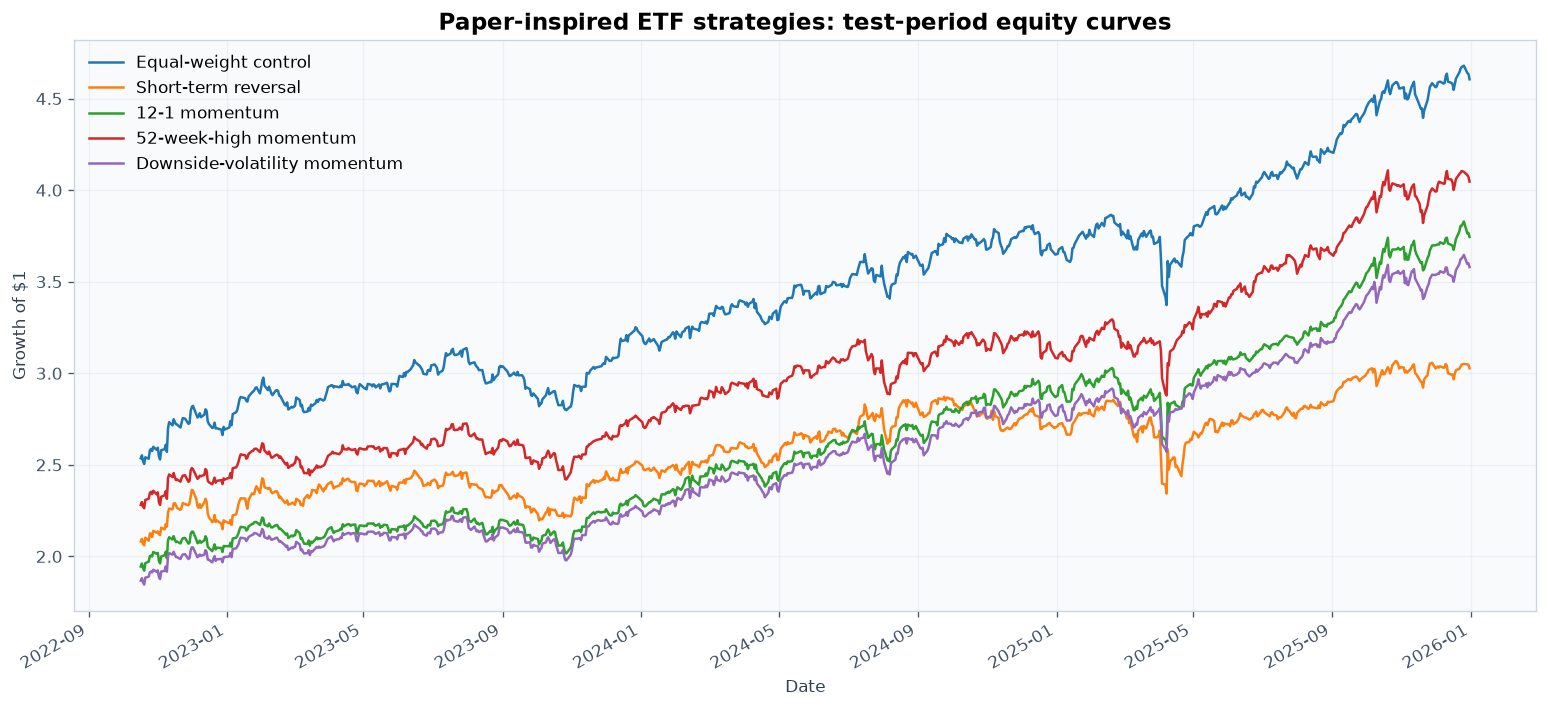

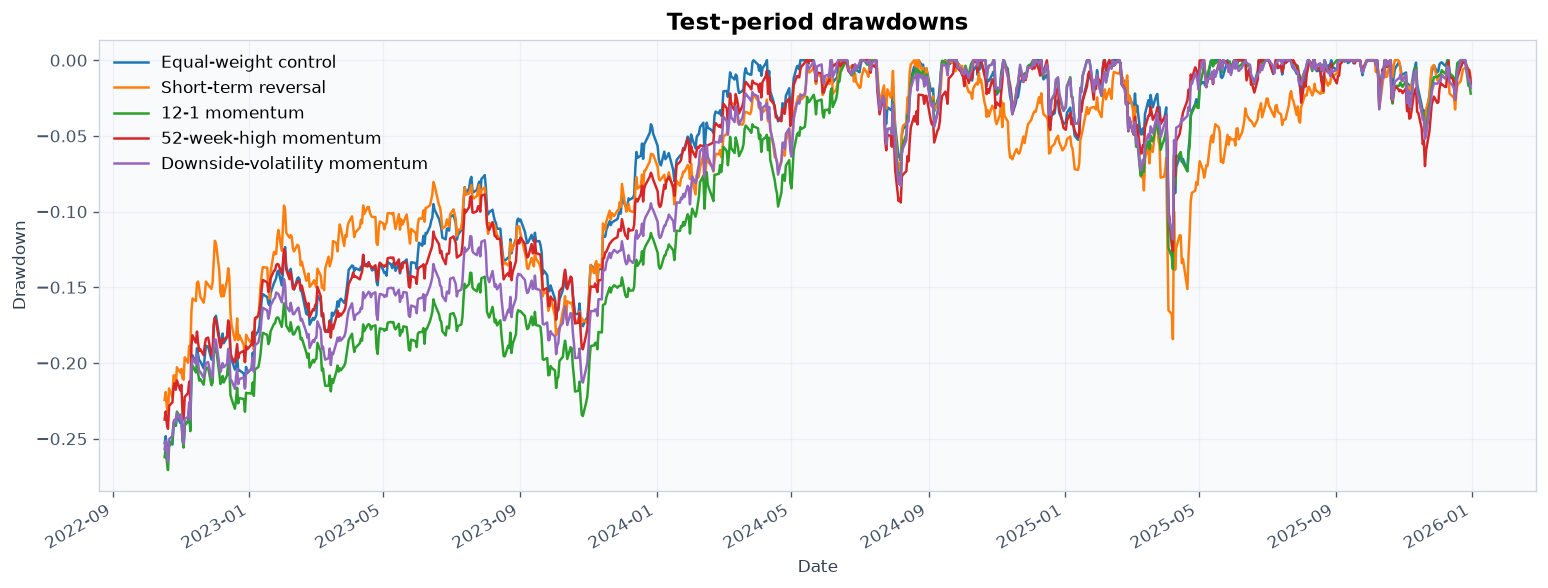

In [5]:
ax = None
for name, result in results.items():
    normalized_equity = result.frame['equity'] / result.frame['equity'].iloc[0]
    ax = normalized_equity.loc[splits['test'].index].plot(ax=ax, figsize=(13, 6), label=name)
ax.set_title('Paper-inspired ETF strategies: test-period equity curves')
ax.set_ylabel('Growth of $1')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

drawdown = pd.DataFrame({name: result.frame['drawdown'] for name, result in results.items()})
drawdown.loc[splits['test'].index].plot(figsize=(13, 5), title='Test-period drawdowns')
plt.ylabel('Drawdown')
plt.grid(alpha=0.25)
plt.show()

## Cost sensitivity

Costs are especially important for reversal because it changes positions frequently and for any strategy that replaces several assets at a rebalance. The table asks whether the ranking is stable as one-way costs move from zero to 50 basis points. This is still a simple model: it does not include spread widening, market impact, taxes, or financing.

In [6]:
cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    for name, target_weights in weights.items():
        cost_result = run_portfolio_backtest(
            close, target_weights, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns
        )
        m = metrics_for_period(cost_result, splits['test'].index)
        cost_rows.append({
            'strategy': name,
            'cost_bps': cost_bps,
            'test_return': m['total_return_after_costs'],
            'test_sharpe': m['sharpe_ratio'],
            'annualized_turnover': m['annualized_turnover'],
        })

cost_table = pd.DataFrame(cost_rows)
cost_table.style.format({
    'test_return': '{:.2%}',
    'test_sharpe': '{:.2f}',
    'annualized_turnover': '{:.2f}',
})

,strategy,cost_bps,test_return,test_sharpe,annualized_turnover
0,Equal-weight control,0,85.23%,1.57,0.00
1,Short-term reversal,0,56.04%,0.97,12.52
2,12-1 momentum,0,99.19%,1.58,4.38
3,52-week-high momentum,0,84.93%,1.50,7.51
4,Downside-volatility momentum,0,98.10%,1.63,5.25
5,Equal-weight control,5,85.23%,1.57,0.00
6,Short-term reversal,5,52.94%,0.93,12.52
7,12-1 momentum,5,97.80%,1.56,4.38
8,52-week-high momentum,5,82.72%,1.47,7.51
9,Downside-volatility momentum,5,96.45%,1.61,5.25


## Validation sweep: rank declared variants before looking at the test

A research workflow should decide parameters using training/validation data and report the final test once. Here we compare a few pre-declared variants on the validation period. The test column is shown for diagnosis, not as permission to keep searching until a winner appears. If many variants are tried, the chance of finding an impressive result by luck increases: this is the multiple-testing problem discussed in the backtest-overfitting reference in the README.

In [7]:
candidate_builders = {
    'Short-term reversal': lambda lookback: short_term_reversal_weights(close, lookback=lookback, top_n=3),
    '12-1 momentum': lambda lookback: cross_sectional_momentum_weights(close, lookback=lookback, skip_recent=21, top_n=3),
    '52-week-high momentum': lambda lookback: fifty_two_week_high_weights(close, lookback=lookback, top_n=3),
    'Downside-volatility momentum': lambda lookback: downside_volatility_momentum_weights(
        close, momentum_lookback=lookback, skip_recent=21, volatility_lookback=60, top_n=3
    ),
}
candidate_grid = {
    'Short-term reversal': [10, 21, 42],
    '12-1 momentum': [126, 252, 378],
    '52-week-high momentum': [126, 252, 378],
    'Downside-volatility momentum': [126, 252, 378],
}

rows = []
for family, lookbacks in candidate_grid.items():
    for lookback in lookbacks:
        candidate_result = run_portfolio_backtest(
            close, candidate_builders[family](lookback),
            transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns,
        )
        validation = metrics_for_period(candidate_result, splits['validation'].index)
        test = metrics_for_period(candidate_result, splits['test'].index)
        rows.append({
            'family': family,
            'lookback': lookback,
            'validation_sharpe': validation['sharpe_ratio'],
            'validation_return': validation['total_return_after_costs'],
            'test_sharpe_diagnostic': test['sharpe_ratio'],
            'test_return_diagnostic': test['total_return_after_costs'],
        })

validation_sweep = pd.DataFrame(rows).sort_values(['family', 'validation_sharpe'], ascending=[True, False])
validation_sweep.style.format({
    'validation_sharpe': '{:.2f}',
    'validation_return': '{:.2%}',
    'test_sharpe_diagnostic': '{:.2f}',
    'test_return_diagnostic': '{:.2%}',
})

,family,lookback,validation_sharpe,validation_return,test_sharpe_diagnostic,test_return_diagnostic
3,12-1 momentum,126,0.49,24.69%,1.58,100.09%
5,12-1 momentum,378,0.22,7.61%,1.68,106.44%
4,12-1 momentum,252,0.12,1.69%,1.54,96.43%
6,52-week-high momentum,126,0.57,27.90%,1.40,77.29%
7,52-week-high momentum,252,0.56,26.54%,1.44,80.54%
8,52-week-high momentum,378,0.54,25.81%,1.50,84.82%
9,Downside-volatility momentum,126,0.53,26.83%,1.64,99.63%
11,Downside-volatility momentum,378,0.18,5.16%,1.69,99.18%
10,Downside-volatility momentum,252,0.17,4.66%,1.60,94.81%
2,Short-term reversal,42,0.26,11.27%,1.25,79.69%


## Beginner interpretation checklist

Write down your answers before changing the code:

1. Which effects survived costs, and which were mostly a turnover story?
2. Did the validation ranking carry into the test period?
3. Did 12-1 momentum and 52-week-high momentum choose the same ETFs? If not, what does that say about their signals?
4. Did downside-volatility weighting reduce drawdown or volatility, and what did it cost in raw return?
5. What is missing before calling this investable research? Examples include point-in-time constituents, delistings, bid-ask spreads, market impact, taxes, leverage, shorting constraints, and a larger out-of-sample history.

The honest conclusion may be that an effect is weaker in a small ETF universe or disappears after costs. That is a useful result: it tells us what the adaptation can and cannot support.

## ⚖️ What went well / what went wrong

**What went well:** The 12–1 momentum and downside-volatility adaptations produced strong risk-adjusted results in the current test sample, while the notebook clearly links each signal to a published paper and records costs, turnover, and validation results.

**What went wrong:** Short-term reversal had much higher turnover and performed poorly after costs. The 52-week-high and momentum rules are not exact replications because the experiment uses seven ETFs rather than stock-level long-short portfolios. Value is intentionally omitted because the loader does not provide point-in-time fundamentals.

Treat the reported Sharpe ratios as sample evidence, not as estimates of a permanent edge.